In [4]:
!pip -q install xgboost

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from xgboost import XGBClassifier

In [5]:
#1. Loading the Data

cab_df = pd.read_csv("cab_rides.csv")
weather_df = pd.read_csv("weather.csv")

In [6]:
#2. Cleaning up data and converting conflicting timestamps

cab_df = cab_df.dropna(subset=["price"]).copy()

#Converting timestamps
cab_df["datetime"] = pd.to_datetime(cab_df["time_stamp"], unit="ms", errors="coerce")
weather_df["datetime"] = pd.to_datetime(weather_df["time_stamp"], unit="s", errors="coerce")

cab_df = cab_df.dropna(subset=["datetime"])
weather_df = weather_df.dropna(subset=["datetime"])

#Sorting to merge later
cab_df = cab_df.sort_values(["source", "datetime"])
weather_df = weather_df.sort_values(["location", "datetime"])

In [7]:
#3. Merging

#Dropping missing keys
cab_df = cab_df.dropna(subset=["datetime", "source"]).copy()
weather_df = weather_df.dropna(subset=["datetime", "location"]).copy()

#Checking types
cab_df["datetime"] = pd.to_datetime(cab_df["datetime"], errors="coerce")
weather_df["datetime"] = pd.to_datetime(weather_df["datetime"], errors="coerce")

cab_df["source"] = cab_df["source"].astype(str)
weather_df["location"] = weather_df["location"].astype(str)

#Dropping invalid rows
cab_df = cab_df.dropna(subset=["datetime", "source"]).copy()
weather_df = weather_df.dropna(subset=["datetime", "location"]).copy()

#Sorting by datetime, then grouping by column
cab_df = cab_df.sort_values(["datetime", "source"]).reset_index(drop=True)
weather_df = weather_df.sort_values(["datetime", "location"]).reset_index(drop=True)

merged_df = pd.merge_asof(
    cab_df,
    weather_df,
    left_on="datetime",
    right_on="datetime",
    left_by="source",
    right_by="location",
    direction="nearest",
    tolerance=pd.Timedelta("2H")
)

In [8]:
#4. Feature engineering
merged_df["hour"] = merged_df["datetime"].dt.hour
merged_df["day"] = merged_df["datetime"].dt.day
merged_df["month"] = merged_df["datetime"].dt.month
merged_df["dayofweek"] = merged_df["datetime"].dt.dayofweek
merged_df["is_weekend"] = (merged_df["dayofweek"] >= 5).astype(int)

In [9]:
#5. Labelling the class (price)

q1 = merged_df["price"].quantile(0.33)
q2 = merged_df["price"].quantile(0.67)

def price_category(p):
    if p <= q1:
        return "low"
    elif p <= q2:
        return "medium"
    else:
        return "high"

merged_df["price_category"] = merged_df["price"].apply(price_category)

In [10]:
#6. Features using
features = [
    "distance", "cab_type", "name", "source", "destination",
    "hour", "day", "month", "dayofweek", "is_weekend",
    "surge_multiplier", "temp", "clouds", "pressure",
    "rain", "humidity", "wind"
]

features = [f for f in features if f in merged_df.columns]

X = merged_df[features]
y = merged_df["price_category"]

In [11]:
#7. Preprocessing
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "bool"]).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), numeric_features),

        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), categorical_features)
    ]
)

# Encode labels for XGBoost
le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [12]:
#8. Train, test split


X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

In [13]:
#9. Training XGBoost

model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="mlogloss",
        random_state=42
    ))
])

print("Training the model...")
model.fit(X_train, y_train)

Training the model...


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['distance', 'is_weekend',
                                                   'surge_multiplier', 'temp',
                                                   'clouds', 'pressure', 'rain',
                                                   'humidity', 'wind']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHo...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=6, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=200, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [14]:
#10. Eval
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average="macro")

print("\nXGBoost Results:")
print("Accuracy:", accuracy)
print("Macro-F1:", f1)



XGBoost Results:
Accuracy: 0.906597642912215
Macro-F1: 0.9076228799655276


In [15]:
#11. Confidence interbals

def bootstrap_ci(y_true, y_pred, metric, n=300):
    rng = np.random.default_rng(42)
    scores = []
    for _ in range(n):
        idx = rng.integers(0, len(y_true), len(y_true))
        scores.append(metric(y_true[idx], y_pred[idx]))
    return np.percentile(scores, [2.5, 97.5])

acc_ci = bootstrap_ci(y_test, y_pred, accuracy_score)
f1_ci = bootstrap_ci(y_test, y_pred, lambda yt, yp: f1_score(yt, yp, average='macro'))

print("\n95% Confidence Intervals:")
print("Accuracy CI:", acc_ci)
print("Macro-F1 CI:", f1_ci)


95% Confidence Intervals:
Accuracy CI: [0.90059203 0.91256196]
Macro-F1 CI: [0.90211476 0.91358825]


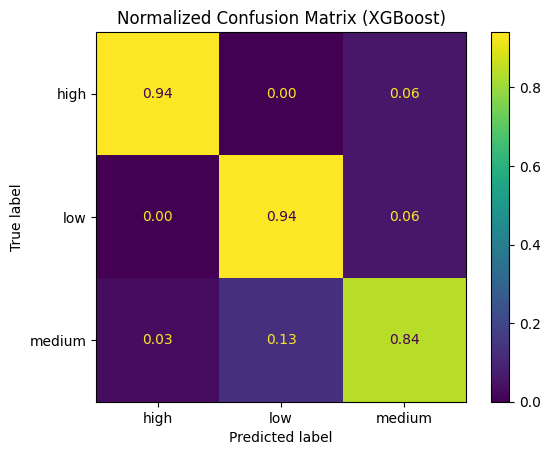

In [16]:
#12. confusion matrix

labels = le.classes_

cm = confusion_matrix(y_test, y_pred, normalize="true")

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(values_format=".2f")
plt.title("Normalized Confusion Matrix (XGBoost)")
plt.show()